In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, time, os, json
from pathlib import Path
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score, precision_score, recall_score
import tifffile
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ {DEVICE}')

✓ cuda


In [2]:
# ================================================================
# SUBIT-BELNAP COMBINER v2 — Vesuvius Challenge
# ================================================================
# Виправлено:
#   - truth table (A^B = BOTH, A&B = INK)
#   - soft-Belnap через evidence accumulation
#   - 3-domain combiner (central / upper / lower layers)
#   - Belnap entropy map
#   - SUBIT-INK score
# ================================================================
 
 
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 1 — Середовище
# ════════════════════════════════════════════════════════════════
import os, torch, numpy as np
from pathlib import Path
 
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}  '
              f'({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
 
INK_PATHS = list(Path('/kaggle/input').rglob('inklabels.png'))
TIF_DIRS  = list(set(p.parent for p in Path('/kaggle/input').rglob('*.tif')))
assert INK_PATHS, "Add Data → vesuvius-challenge-ink-detection"
INK_PATH  = INK_PATHS[0]
VOL_DIR   = sorted(TIF_DIRS, key=lambda p: len(list(p.glob('*.tif'))), reverse=True)[0]
tif_files = sorted(VOL_DIR.glob('*.tif'))
print(f'✓ Шарів: {len(tif_files)}  INK: {INK_PATH}')

PyTorch: 2.10.0+cu128
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)
Device: cuda
✓ Шарів: 65  INK: /kaggle/input/competitions/vesuvius-challenge-ink-detection/train/2/inklabels.png


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (140973980 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Завантажуємо 65 шарів...
  10/65
  20/65
  30/65
  40/65
  50/65
  60/65

Volume: (65, 2048, 2048)
Domain A: шари 29:36 (central)
Domain B: шари 21:28 (upper)
Domain C: шари 37:44 (lower)
Ink coverage: 18.6%


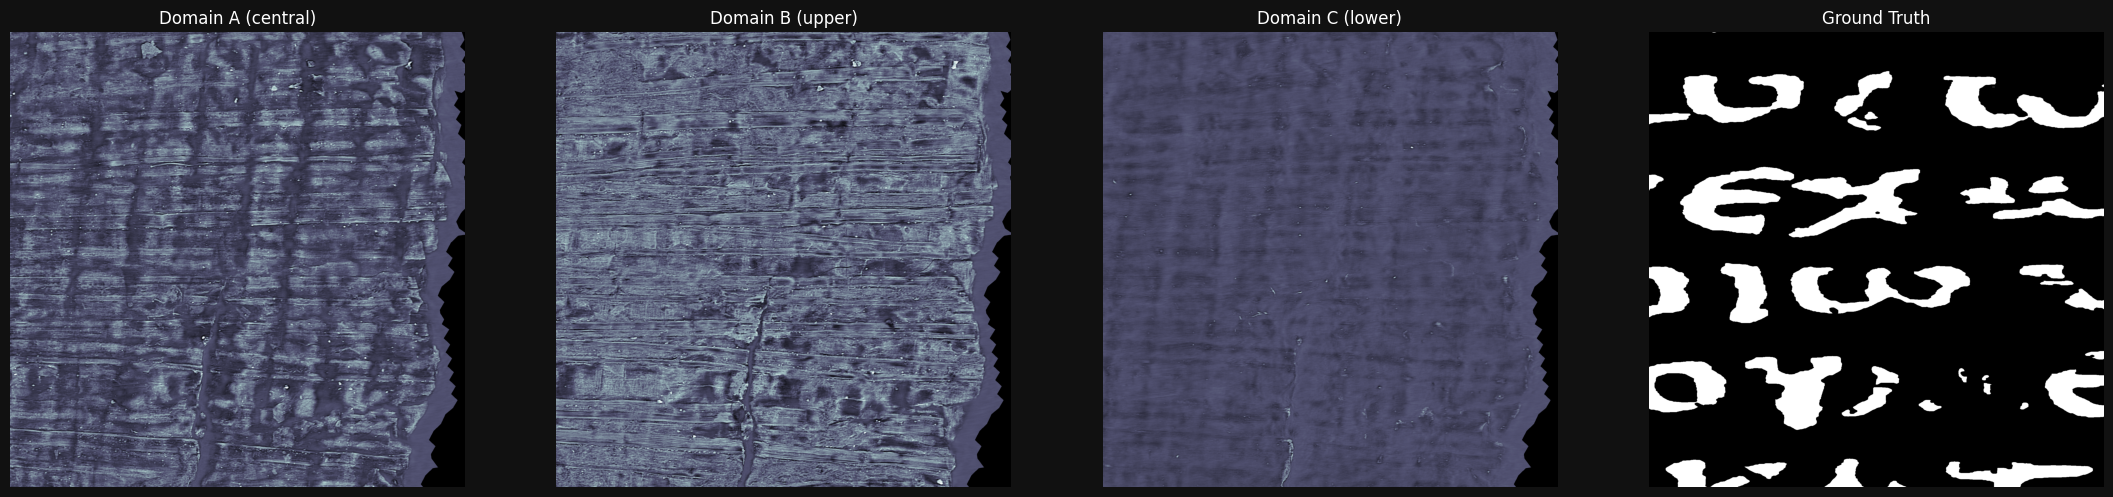

✓ Три домени готові


In [3]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 2 — Дані + три домени
# ════════════════════════════════════════════════════════════════
import tifffile
from PIL import Image
 
LAYERS    = 65
CROP_SIZE = 2048
DEPTH     = 7
 
ink_full = (np.array(Image.open(str(INK_PATH)).convert('L')) > 128).astype(np.float32)
H_ink, W_ink = ink_full.shape
sample   = tifffile.imread(str(tif_files[0]))
H_tif, W_tif = sample.shape[-2], sample.shape[-1]
scale_y, scale_x = H_tif/H_ink, W_tif/W_ink
iy, ix   = np.where(ink_full > 0)
cy_ink, cx_ink = int(iy.mean()), int(ix.mean())
cy_tif = int(cy_ink*scale_y); cx_tif = int(cx_ink*scale_x)
hc = CROP_SIZE//2
y1 = max(0,min(cy_tif-hc,H_tif-CROP_SIZE)); x1 = max(0,min(cx_tif-hc,W_tif-CROP_SIZE))
y2,x2 = y1+CROP_SIZE,x1+CROP_SIZE
y1i,y2i = int(y1/scale_y),int(y2/scale_y)
x1i,x2i = int(x1/scale_x),int(x2/scale_x)
 
print(f'Завантажуємо {min(LAYERS,len(tif_files))} шарів...')
layers = []
for i,f in enumerate(tif_files[:LAYERS]):
    raw = tifffile.imread(str(f))
    if raw.ndim==3: raw=raw[0]
    layers.append(raw[y1:y2,x1:x2].astype(np.float32))
    if (i+1)%10==0: print(f'  {i+1}/{min(LAYERS,len(tif_files))}')
 
volume = np.stack(layers)
v_min,v_max = float(volume.min()),float(volume.max())
volume = (volume-v_min)/(v_max-v_min+1e-8)
ink_crop = ink_full[y1i:y2i,x1i:x2i]
ink = np.array(Image.fromarray(ink_crop).resize(
    (volume.shape[2],volume.shape[1]),Image.NEAREST))
 
# ── Три незалежні домени ──
mid  = volume.shape[0]//2
half = DEPTH//2
shift = 8
 
# Domain A: центральні шари (core signal)
vol_A = volume[mid-half : mid+half+1].mean(axis=0).astype(np.float32)
# Domain B: верхні шари (upper surface)
vol_B = volume[mid-half-shift : mid+half+1-shift].mean(axis=0).astype(np.float32)
# Domain C: нижні шари (lower surface)
vol_C = volume[mid-half+shift : mid+half+1+shift].mean(axis=0).astype(np.float32)
 
print(f'\nVolume: {volume.shape}')
print(f'Domain A: шари {mid-half}:{mid+half+1} (central)')
print(f'Domain B: шари {mid-half-shift}:{mid+half+1-shift} (upper)')
print(f'Domain C: шари {mid-half+shift}:{mid+half+1+shift} (lower)')
print(f'Ink coverage: {ink.mean()*100:.1f}%')
 
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,4,figsize=(22,5)); fig.patch.set_facecolor('#111')
for ax in axes: ax.set_facecolor('#111'); ax.axis('off')
axes[0].imshow(vol_A,cmap='bone'); axes[0].set_title('Domain A (central)',color='white')
axes[1].imshow(vol_B,cmap='bone'); axes[1].set_title('Domain B (upper)',color='white')
axes[2].imshow(vol_C,cmap='bone'); axes[2].set_title('Domain C (lower)',color='white')
axes[3].imshow(ink,  cmap='gray'); axes[3].set_title('Ground Truth',color='white')
plt.tight_layout(); plt.show()
print('✓ Три домени готові')

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score, precision_score, recall_score
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score, precision_score, recall_score
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {DEVICE}')
print('✓ Імпорти готові')

✓ Device: cuda
✓ Імпорти готові


In [5]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 3 — Модель + ВИПРАВЛЕНИЙ Belnap Combiner
# ════════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score, precision_score, recall_score
import time
 
class DC2d(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.b=nn.Sequential(
            nn.Conv2d(i,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
            nn.Conv2d(o,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.b(x)
 
class InkNet(nn.Module):
    def __init__(self,base=32):
        super().__init__()
        self.e1=DC2d(1,base)
        self.e2=nn.Sequential(nn.MaxPool2d(2),DC2d(base,base*2))
        self.e3=nn.Sequential(nn.MaxPool2d(2),DC2d(base*2,base*4))
        self.bot=DC2d(base*4,base*8)
        self.d3=DC2d(base*8+base*4,base*4)
        self.d2=DC2d(base*4+base*2,base*2)
        self.d1=DC2d(base*2+base,base)
        self.head=nn.Conv2d(base,1,1)
    def forward(self,x):
        e1=self.e1(x);e2=self.e2(e1);e3=self.e3(e2);b=self.bot(e3)
        d3=self.d3(torch.cat([F.interpolate(b, size=e3.shape[2:],mode='bilinear',align_corners=False),e3],1))
        d2=self.d2(torch.cat([F.interpolate(d3,size=e2.shape[2:],mode='bilinear',align_corners=False),e2],1))
        d1=self.d1(torch.cat([F.interpolate(d2,size=e1.shape[2:],mode='bilinear',align_corners=False),e1],1))
        return self.head(d1)
 
# ── ВИПРАВЛЕНИЙ Hard Belnap Combiner ──
# Правильна truth table:
#   A=1, B=1 → INK  (2)   — cross-domain agreement
#   A=1, B=0 → BOTH (3)   — domain conflict
#   A=0, B=1 → BOTH (3)   — domain conflict
#   A=0, B=0 → VOID (1)   — agreement negative
#   both uncertain → UNKNOWN (0)
def belnap_combine_hard(prob_A: np.ndarray, prob_B: np.ndarray,
                         thr: float = 0.5) -> np.ndarray:
    A = prob_A > thr
    B = prob_B > thr
    uncertain = ((prob_A > 0.3) & (prob_A < 0.7) &
                 (prob_B > 0.3) & (prob_B < 0.7))
    result = np.ones(prob_A.shape, dtype=np.int32)  # default: VOID
    result[A & B]  = 2   # INK
    result[A ^ B]  = 3   # BOTH (XOR = один каже так, інший ні)
    result[uncertain] = 0  # UNKNOWN
    return result
 
# ── Soft Belnap через evidence accumulation ──
def belnap_combine_soft(prob_A: np.ndarray, prob_B: np.ndarray,
                         *probs_extra) -> dict:
    """
    Soft-Belnap via Dempster-Shafer evidence accumulation.
    Не втрачає інформацію на порозі.
 
    evidence_ink(A)  = prob_A
    evidence_void(A) = 1 - prob_A
 
    belief_ink  = min(ev_ink_A,  ev_ink_B)   — обидва кажуть "є"
    belief_void = min(ev_void_A, ev_void_B)  — обидва кажуть "нема"
    conflict    = взаємовиключні свідчення
 
    Повертає:
      belief_ink, belief_void, conflict, uncertainty
    """
    all_probs = [prob_A, prob_B] + list(probs_extra)
 
    # Ініціалізуємо з першої моделі
    ev_ink  = all_probs[0].copy()
    ev_void = 1.0 - all_probs[0]
 
    for p in all_probs[1:]:
        ev_ink_new  = p
        ev_void_new = 1.0 - p
 
        # Акумулюємо мінімальне свідчення (консервативна комбінація)
        belief_ink   = np.minimum(ev_ink,  ev_ink_new)
        belief_void  = np.minimum(ev_void, ev_void_new)
        # Конфлікт: A каже є, B каже немає (або навпаки)
        conflict     = (np.minimum(ev_ink,  ev_void_new) +
                        np.minimum(ev_void, ev_ink_new))
        # Невизначеність: ніхто не впевнений
        uncertainty  = 1.0 - belief_ink - belief_void - conflict
 
        ev_ink  = belief_ink
        ev_void = belief_void
 
    return {
        'belief_ink':   ev_ink,
        'belief_void':  ev_void,
        'conflict':     conflict,
        'uncertainty':  np.clip(uncertainty, 0, 1),
    }
 
def soft_to_belnap(soft: dict, thr: float = 0.4) -> np.ndarray:
    """Перетворює soft evidence у дискретні стани Белнапа."""
    result = np.ones(soft['belief_ink'].shape, dtype=np.int32)  # VOID
    result[soft['belief_ink']  > thr] = 2  # INK
    result[soft['conflict']    > thr] = 3  # BOTH
    result[soft['uncertainty'] > thr] = 0  # UNKNOWN
    return result
 
# ── Belnap Entropy ──
def belnap_entropy(soft: dict) -> np.ndarray:
    """
    H_B = -Σ p(s) * log2(p(s))  для s ∈ {INK, BOTH, VOID, UNKNOWN}
    Висока ентропія = нестабільна зона.
    """
    total = (soft['belief_ink'] + soft['belief_void'] +
             soft['conflict'] + soft['uncertainty'] + 1e-8)
    p_ink  = soft['belief_ink']   / total
    p_void = soft['belief_void']  / total
    p_both = soft['conflict']     / total
    p_unk  = soft['uncertainty']  / total
 
    def xlogx(p): return -p * np.log2(np.clip(p, 1e-8, 1))
    return xlogx(p_ink) + xlogx(p_void) + xlogx(p_both) + xlogx(p_unk)
 
# ── SUBIT-INK Score ──
def subit_ink_score(belnap_map: np.ndarray, gt: np.ndarray,
                     border: np.ndarray) -> dict:
    """
    SUBIT-INK Score = Precision(INK) × ConflictLocalization(BOTH)
 
    ConflictLocalization = частка BOTH пікселів що знаходяться
    на реальних межах букв або у зонах артефактів.
    Якщо BOTH хаотично розкиданий → низький score.
    """
    ink_pred = (belnap_map == 2).astype(int)
    both     = (belnap_map == 3)
 
    prec = precision_score(gt.flatten().astype(int),
                           ink_pred.flatten(), zero_division=0)
    # Частка BOTH що припадає на межі букв
    conflict_loc = (both & border).sum() / (both.sum() + 1e-8)
 
    return {
        'precision_ink':    float(prec),
        'conflict_loc':     float(conflict_loc),
        'subit_ink_score':  float(prec * conflict_loc),
    }
 
BELNAP_COLORS = {2:(0,200,255), 3:(255,165,0), 1:(20,20,20), 0:(128,0,128)}
BELNAP_LABELS = {
    2:'INK (T) — cross-domain agreement',
    3:'BOTH (B) — domain conflict',
    1:'VOID (F) — agreement negative',
    0:'UNKNOWN (N) — all uncertain',
}
 
def make_labels(ink_mask, dil=4):
    ink = ink_mask.astype(bool)
    border = binary_dilation(ink, iterations=dil) & ~ink
    soft = ink.astype(np.float32)
    soft[border] = 0.7
    return soft
 
def train_model(model, img, labels, epochs=50, pw=5.0, bs=32, ps=64):
    from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
    class PatchDS(Dataset):
        def __init__(self,img,labels,n=3000,ps=64):
            self.img=img;self.labels=labels;self.ps=ps;self.hp=ps//2
            H,W=img.shape;hp=self.hp;rng=np.random.default_rng(42)
            iy,ix=np.where(labels>0.5);vy,vx=np.where(labels<0.3)
            n_ink=int(n*0.4);n_void=n-n_ink
            def sc(ya,xa,nn):
                if len(ya)==0: return []
                idx=rng.integers(0,len(ya),nn*3);res=[]
                for i in idx:
                    y,x=ya[i],xa[i]
                    if hp<=y<H-hp and hp<=x<W-hp: res.append((y,x))
                    if len(res)>=nn: break
                return res[:nn]
            self.coords=sc(iy,ix,n_ink)+sc(vy,vx,n_void)
        def __len__(self): return len(self.coords)
        def __getitem__(self,idx):
            py,px=self.coords[idx];hp=self.hp
            return (torch.from_numpy(self.img[py-hp:py+hp,px-hp:px+hp]).float().unsqueeze(0),
                    torch.from_numpy(self.labels[py-hp:py+hp,px-hp:px+hp]).float().unsqueeze(0))
 
    ds=PatchDS(img,labels,n=3000,ps=ps)
    n=len(ds);idx=list(range(n));np.random.shuffle(idx);split=int(0.8*n)
    tl=DataLoader(ds,bs,sampler=SubsetRandomSampler(idx[:split]),num_workers=2,pin_memory=True)
    vl=DataLoader(ds,bs,sampler=SubsetRandomSampler(idx[split:]),num_workers=2,pin_memory=True)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs)
    pw_t=torch.tensor([pw]).to(DEVICE);model.to(DEVICE)
    best_val=float('inf');best_st=None;th=[];vh=[];t0=time.time()
    for ep in range(epochs):
        model.train();tot=0;nb=0
        for x,y in tl:
            opt.zero_grad()
            loss=nn.BCEWithLogitsLoss(pos_weight=pw_t)(model(x.to(DEVICE)),y.to(DEVICE))
            loss.backward();opt.step();tot+=loss.item();nb+=1
        tl_=tot/max(nb,1)
        model.eval();tot=0;nb=0
        with torch.no_grad():
            for x,y in vl:
                loss=nn.BCEWithLogitsLoss(pos_weight=pw_t)(model(x.to(DEVICE)),y.to(DEVICE))
                tot+=loss.item();nb+=1
        vl_=tot/max(nb,1);sched.step();th.append(tl_);vh.append(vl_)
        if vl_<best_val:
            best_val=vl_;best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
        eta=(time.time()-t0)/(ep+1)*(epochs-ep-1)
        print(f'  ep {ep+1:3d}/{epochs}  train={tl_:.4f}  val={vl_:.4f}  ETA={eta/60:.1f}хв')
    model.load_state_dict(best_st)
    print(f'  ✓ Best val={best_val:.4f}')
    return th,vh
 
@torch.no_grad()
def predict_full(model,img,ps=64,step=None):
    H,W=img.shape;hp=ps//2;step=step or ps//2
    pm=np.zeros((H,W),np.float32);cnt=np.zeros((H,W),np.float32)
    model.eval()
    tiles=[(py,px) for py in range(hp,H-hp,step) for px in range(hp,W-hp,step)]
    bs=128
    for i in range(0,len(tiles),bs):
        bt=tiles[i:i+bs];imgs=[];valid=[]
        for py,px in bt:
            p=img[py-hp:py+hp,px-hp:px+hp]
            if p.shape==(ps,ps): imgs.append(torch.from_numpy(p).float());valid.append((py,px))
        if not imgs: continue
        bt2=torch.stack(imgs).unsqueeze(1).to(DEVICE)
        prob=torch.sigmoid(model(bt2)).squeeze(1).cpu().numpy()
        for j,(py,px) in enumerate(valid):
            pm[py-hp:py+hp,px-hp:px+hp]+=prob[j]
            cnt[py-hp:py+hp,px-hp:px+hp]+=1
        if (i//bs)%20==0: print(f'  {min(i+bs,len(tiles))}/{len(tiles)} ({100*min(i+bs,len(tiles))/len(tiles):.0f}%)')
    return pm/np.maximum(cnt,1)
 
test=InkNet(32).to(DEVICE)
x=torch.zeros(4,1,64,64).to(DEVICE)
print(f'✓ InkNet: {tuple(test(x).shape)}  params={sum(p.numel() for p in test.parameters()):,}')
del test,x; torch.cuda.empty_cache()

✓ InkNet: (4, 1, 64, 64)  params=1,947,713


ink_full: 14830×9506
Центр тексту (ink): y=8489, x=4451
Новий crop (ink): y=7739:9239, x=3701:5201
Новий crop (tif): y=2846:3397, x=2464:3463
Ink у новому crop: 20.5%

Завантажуємо шари з правильним crop...
  10/65
  20/65
  30/65
  40/65
  50/65
  60/65

Volume: (65, 551, 999)
Ink: 20.5%


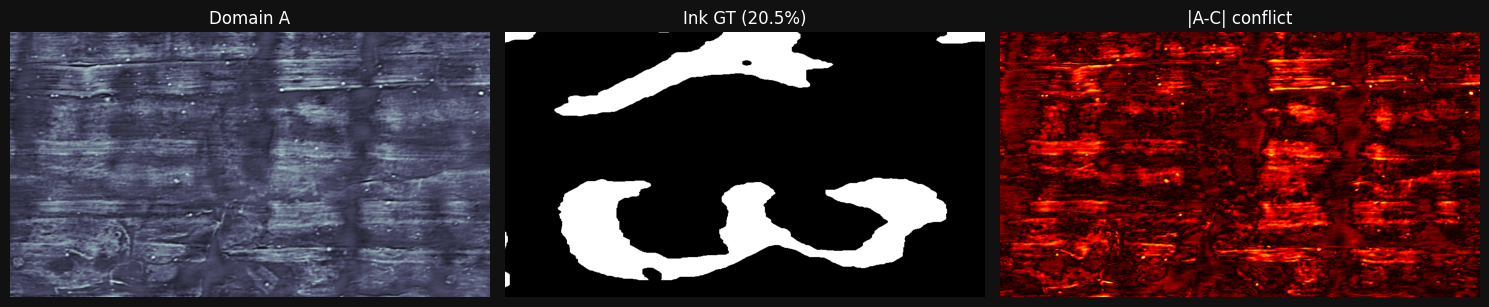

✓ Новий crop готовий — тепер запускай клітинки 4→5→6→7


In [6]:
# Виправляємо crop — беремо центр тексту правильно
from PIL import Image

H_ink, W_ink = ink_full.shape
print(f'ink_full: {H_ink}×{W_ink}')

# Центр тексту в координатах ink
cy_ink_real = int(iy.mean())
cx_ink_real = int(ix.mean())
print(f'Центр тексту (ink): y={cy_ink_real}, x={cx_ink_real}')

# Crop у координатах ink (не tif!)
CROP_INK = 1500  # розмір crop в пікселях ink
hc = CROP_INK // 2
y1_new = max(0, min(cy_ink_real - hc, H_ink - CROP_INK))
y2_new = y1_new + CROP_INK
x1_new = max(0, min(cx_ink_real - hc, W_ink - CROP_INK))
x2_new = x1_new + CROP_INK
print(f'Новий crop (ink): y={y1_new}:{y2_new}, x={x1_new}:{x2_new}')

# Відповідні координати в tif
y1_tif = int(y1_new * scale_y); y2_tif = int(y2_new * scale_y)
x1_tif = int(x1_new * scale_x); x2_tif = int(x2_new * scale_x)
print(f'Новий crop (tif): y={y1_tif}:{y2_tif}, x={x1_tif}:{x2_tif}')

# Нова ink маска
ink_new = ink_full[y1_new:y2_new, x1_new:x2_new]
print(f'Ink у новому crop: {ink_new.mean()*100:.1f}%')

# Завантажуємо новий volume
print(f'\nЗавантажуємо шари з правильним crop...')
layers_new = []
for i, f in enumerate(tif_files[:LAYERS]):
    raw = tifffile.imread(str(f))
    if raw.ndim == 3: raw = raw[0]
    layers_new.append(raw[y1_tif:y2_tif, x1_tif:x2_tif].astype(np.float32))
    if (i+1) % 10 == 0: print(f'  {i+1}/{LAYERS}')

volume_new = np.stack(layers_new)
v_min, v_max = float(volume_new.min()), float(volume_new.max())
volume_new = (volume_new - v_min) / (v_max - v_min + 1e-8)

# Resize ink під розмір volume
ink = np.array(Image.fromarray(ink_new).resize(
    (volume_new.shape[2], volume_new.shape[1]), Image.NEAREST))
volume = volume_new

# Три домени
mid = volume.shape[0] // 2; half = DEPTH // 2; shift = 8
vol_A = volume[mid-half : mid+half+1].mean(axis=0).astype(np.float32)
vol_B = volume[max(0,mid-half-shift) : max(DEPTH,mid+half+1-shift)].mean(axis=0).astype(np.float32)
vol_C = volume[min(volume.shape[0]-DEPTH,mid-half+shift) : mid+half+1+shift].mean(axis=0).astype(np.float32)

print(f'\nVolume: {volume.shape}')
print(f'Ink: {ink.mean()*100:.1f}%')

# Перевірка
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#111')
for ax in axes: ax.set_facecolor('#111'); ax.axis('off')
axes[0].imshow(vol_A, cmap='bone'); axes[0].set_title('Domain A', color='white')
axes[1].imshow(ink,   cmap='gray'); axes[1].set_title(f'Ink GT ({ink.mean()*100:.1f}%)', color='white')
axes[2].imshow(np.abs(vol_A - vol_C), cmap='hot'); axes[2].set_title('|A-C| conflict', color='white')
plt.tight_layout(); plt.show()
print('✓ Новий crop готовий — тепер запускай клітинки 4→5→6→7')

In [7]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 4 — Тренування трьох незалежних детекторів
# ════════════════════════════════════════════════════════════════
torch.cuda.empty_cache()
ratio=(1-ink).sum()/(ink.sum()+1e-8)
labels=make_labels(ink,dil=4)
 
print('='*55+'\nModel A (central layers)\n'+'='*55)
model_A=InkNet(32); hA_t,hA_v=train_model(model_A,vol_A,labels,50,ratio)
 
print('\n'+'='*55+'\nModel B (upper layers)\n'+'='*55)
model_B=InkNet(32); hB_t,hB_v=train_model(model_B,vol_B,labels,50,ratio)
 
print('\n'+'='*55+'\nModel C (lower layers)\n'+'='*55)
model_C=InkNet(32); hC_t,hC_v=train_model(model_C,vol_C,labels,50,ratio)
 
torch.save(model_A.state_dict(),'/kaggle/working/model_A.pth')
torch.save(model_B.state_dict(),'/kaggle/working/model_B.pth')
torch.save(model_C.state_dict(),'/kaggle/working/model_C.pth')
print('\n✓ Три моделі збережено')
 

Model A (central layers)
  ep   1/50  train=1.1077  val=1.0637  ETA=3.3хв
  ep   2/50  train=0.8764  val=1.3524  ETA=3.0хв
  ep   3/50  train=0.6949  val=0.8011  ETA=2.8хв
  ep   4/50  train=0.5027  val=0.8359  ETA=2.7хв
  ep   5/50  train=0.4337  val=0.6374  ETA=2.6хв
  ep   6/50  train=0.3200  val=0.3358  ETA=2.6хв
  ep   7/50  train=0.2736  val=0.3367  ETA=2.5хв
  ep   8/50  train=0.2646  val=0.5032  ETA=2.4хв
  ep   9/50  train=0.2396  val=0.2480  ETA=2.4хв
  ep  10/50  train=0.1986  val=0.1912  ETA=2.3хв
  ep  11/50  train=0.1700  val=0.2480  ETA=2.3хв
  ep  12/50  train=0.1441  val=0.1701  ETA=2.2хв
  ep  13/50  train=0.1304  val=0.1897  ETA=2.1хв
  ep  14/50  train=0.1138  val=0.1485  ETA=2.1хв
  ep  15/50  train=0.0982  val=0.1201  ETA=2.0хв
  ep  16/50  train=0.0899  val=0.1339  ETA=2.0хв
  ep  17/50  train=0.1045  val=0.1427  ETA=1.9хв
  ep  18/50  train=0.0986  val=0.2236  ETA=1.9хв
  ep  19/50  train=0.0950  val=0.1036  ETA=1.8хв
  ep  20/50  train=0.0702  val=0.0918  ETA=1

In [8]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 5 — Inference + Hard і Soft Belnap
# ════════════════════════════════════════════════════════════════
print('Inference A...'); prob_A=predict_full(model_A,vol_A,64,32)
print('Inference B...'); prob_B=predict_full(model_B,vol_B,64,32)
print('Inference C...'); prob_C=predict_full(model_C,vol_C,64,32)
 
np.save('/kaggle/working/prob_A.npy',prob_A)
np.save('/kaggle/working/prob_B.npy',prob_B)
np.save('/kaggle/working/prob_C.npy',prob_C)
 
# Hard Belnap (2 домени: A vs B)
hard_AB = belnap_combine_hard(prob_A, prob_B, thr=0.5)
 
# Hard Belnap (3 домени: majority vote + conflict)
def belnap_combine_3(pA, pB, pC, thr=0.5):
    A=(pA>thr); B=(pB>thr); C=(pC>thr)
    votes = A.astype(int)+B.astype(int)+C.astype(int)
    uncertain = ((pA>0.3)&(pA<0.7)&(pB>0.3)&(pB<0.7)&(pC>0.3)&(pC<0.7))
    result = np.ones(pA.shape, dtype=np.int32)     # VOID
    result[votes == 3] = 2                          # INK: всі три згодні
    result[(votes == 2) | (votes == 1)] = 3        # BOTH: є розбіжність
    result[votes == 0] = 1                          # VOID: всі кажуть немає
    result[uncertain]  = 0                          # UNKNOWN
    return result
 
hard_3 = belnap_combine_3(prob_A, prob_B, prob_C, thr=0.5)
 
# Soft Belnap (3 домени)
soft = belnap_combine_soft(prob_A, prob_B, prob_C)
soft_map = soft_to_belnap(soft, thr=0.4)
 
# Entropy
entropy_map = belnap_entropy(soft)
 
# Standard ensemble baseline
ensemble = ((prob_A + prob_B + prob_C) / 3 > 0.5).astype(np.int32)
 
np.save('/kaggle/working/hard_AB.npy',   hard_AB)
np.save('/kaggle/working/hard_3.npy',    hard_3)
np.save('/kaggle/working/soft_map.npy',  soft_map)
np.save('/kaggle/working/entropy.npy',   entropy_map)
print('✓ Всі карти збережено')

Inference A...
  128/480 (27%)
Inference B...
  128/480 (27%)
Inference C...
  128/480 (27%)
✓ Всі карти збережено


In [9]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 6 — Метрики: порівняння всіх підходів
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from scipy.ndimage import binary_dilation

gt     = ink.astype(int).flatten()
border = binary_dilation(ink.astype(bool), iterations=4) & ~ink.astype(bool)

def eval_belnap(bmap, name):
    ink_pred = (bmap == 2).astype(int)
    relaxed  = ((bmap == 2) | (bmap == 3)).astype(int)
    f1   = f1_score(gt,   ink_pred.flatten(), zero_division=0)
    f05  = fbeta_score(gt, ink_pred.flatten(), beta=0.5, zero_division=0)
    prec = precision_score(gt, ink_pred.flatten(), zero_division=0)
    rec  = recall_score(gt,    ink_pred.flatten(), zero_division=0)
    f1r  = f1_score(gt, relaxed.flatten(), zero_division=0)
    total = bmap.size
    sc   = subit_ink_score(bmap, ink, border)
    print(f'  {name}:')
    print(f'    F0.5={f05:.4f}  F1={f1:.4f}  prec={prec:.4f}  rec={rec:.4f}')
    print(f'    F1(INK+BOTH)={f1r:.4f}')
    print(f'    INK={100*(bmap==2).sum()/total:.1f}%  '
          f'BOTH={100*(bmap==3).sum()/total:.1f}%  '
          f'VOID={100*(bmap==1).sum()/total:.1f}%  '
          f'UNK={100*(bmap==0).sum()/total:.1f}%')
    print(f'    SUBIT-INK score={sc["subit_ink_score"]:.4f}  '
          f'(prec={sc["precision_ink"]:.3f} × loc={sc["conflict_loc"]:.3f})')
    return f05

# Single models
f1_A   = f1_score(gt, (prob_A > 0.5).astype(int).flatten(), zero_division=0)
f1_B   = f1_score(gt, (prob_B > 0.5).astype(int).flatten(), zero_division=0)
f1_C   = f1_score(gt, (prob_C > 0.5).astype(int).flatten(), zero_division=0)
f05_ens = fbeta_score(gt, ensemble.flatten(), beta=0.5, zero_division=0)

print(f'\n{"="*60}')
print(f'  ПОРІВНЯННЯ МЕТОДІВ (F0.5 = Vesuvius метрика)')
print(f'{"="*60}')
print(f'  Single model A:  F1={f1_A:.4f}')
print(f'  Single model B:  F1={f1_B:.4f}')
print(f'  Single model C:  F1={f1_C:.4f}')
print(f'  Mean ensemble:   F0.5={f05_ens:.4f}')
print()

f05_AB = eval_belnap(hard_AB,  'Hard Belnap (A vs B)')
print()
f05_3  = eval_belnap(hard_3,   'Hard Belnap (3 domains)')
print()
f05_s  = eval_belnap(soft_map, 'Soft Belnap (3 domains)')

print(f'\n{"="*60}')
print(f'  Entropy: mean={entropy_map.mean():.3f}  max={entropy_map.max():.3f}')
print(f'  High entropy zones (>1.5 bits): {(entropy_map > 1.5).mean()*100:.1f}%')
print(f'{"="*60}')


  ПОРІВНЯННЯ МЕТОДІВ (F0.5 = Vesuvius метрика)
  Single model A:  F1=0.9305
  Single model B:  F1=0.9339
  Single model C:  F1=0.9281
  Mean ensemble:   F0.5=0.9005

  Hard Belnap (A vs B):
    F0.5=0.9087  F1=0.9352  prec=0.8918  rec=0.9831
    F1(INK+BOTH)=0.9338
    INK=22.6%  BOTH=0.6%  VOID=76.5%  UNK=0.3%
    SUBIT-INK score=0.3639  (prec=0.892 × loc=0.408)

  Hard Belnap (3 domains):
    F0.5=0.9091  F1=0.9332  prec=0.8936  rec=0.9765
    F1(INK+BOTH)=0.9302
    INK=22.4%  BOTH=1.0%  VOID=76.4%  UNK=0.2%
    SUBIT-INK score=0.3166  (prec=0.894 × loc=0.354)

  Soft Belnap (3 domains):
    F0.5=0.9145  F1=0.9341  prec=0.9018  rec=0.9688
    F1(INK+BOTH)=0.9184
    INK=22.1%  BOTH=1.4%  VOID=75.9%  UNK=0.6%
    SUBIT-INK score=0.4082  (prec=0.902 × loc=0.453)

  Entropy: mean=0.098  max=1.947
  High entropy zones (>1.5 bits): 0.3%


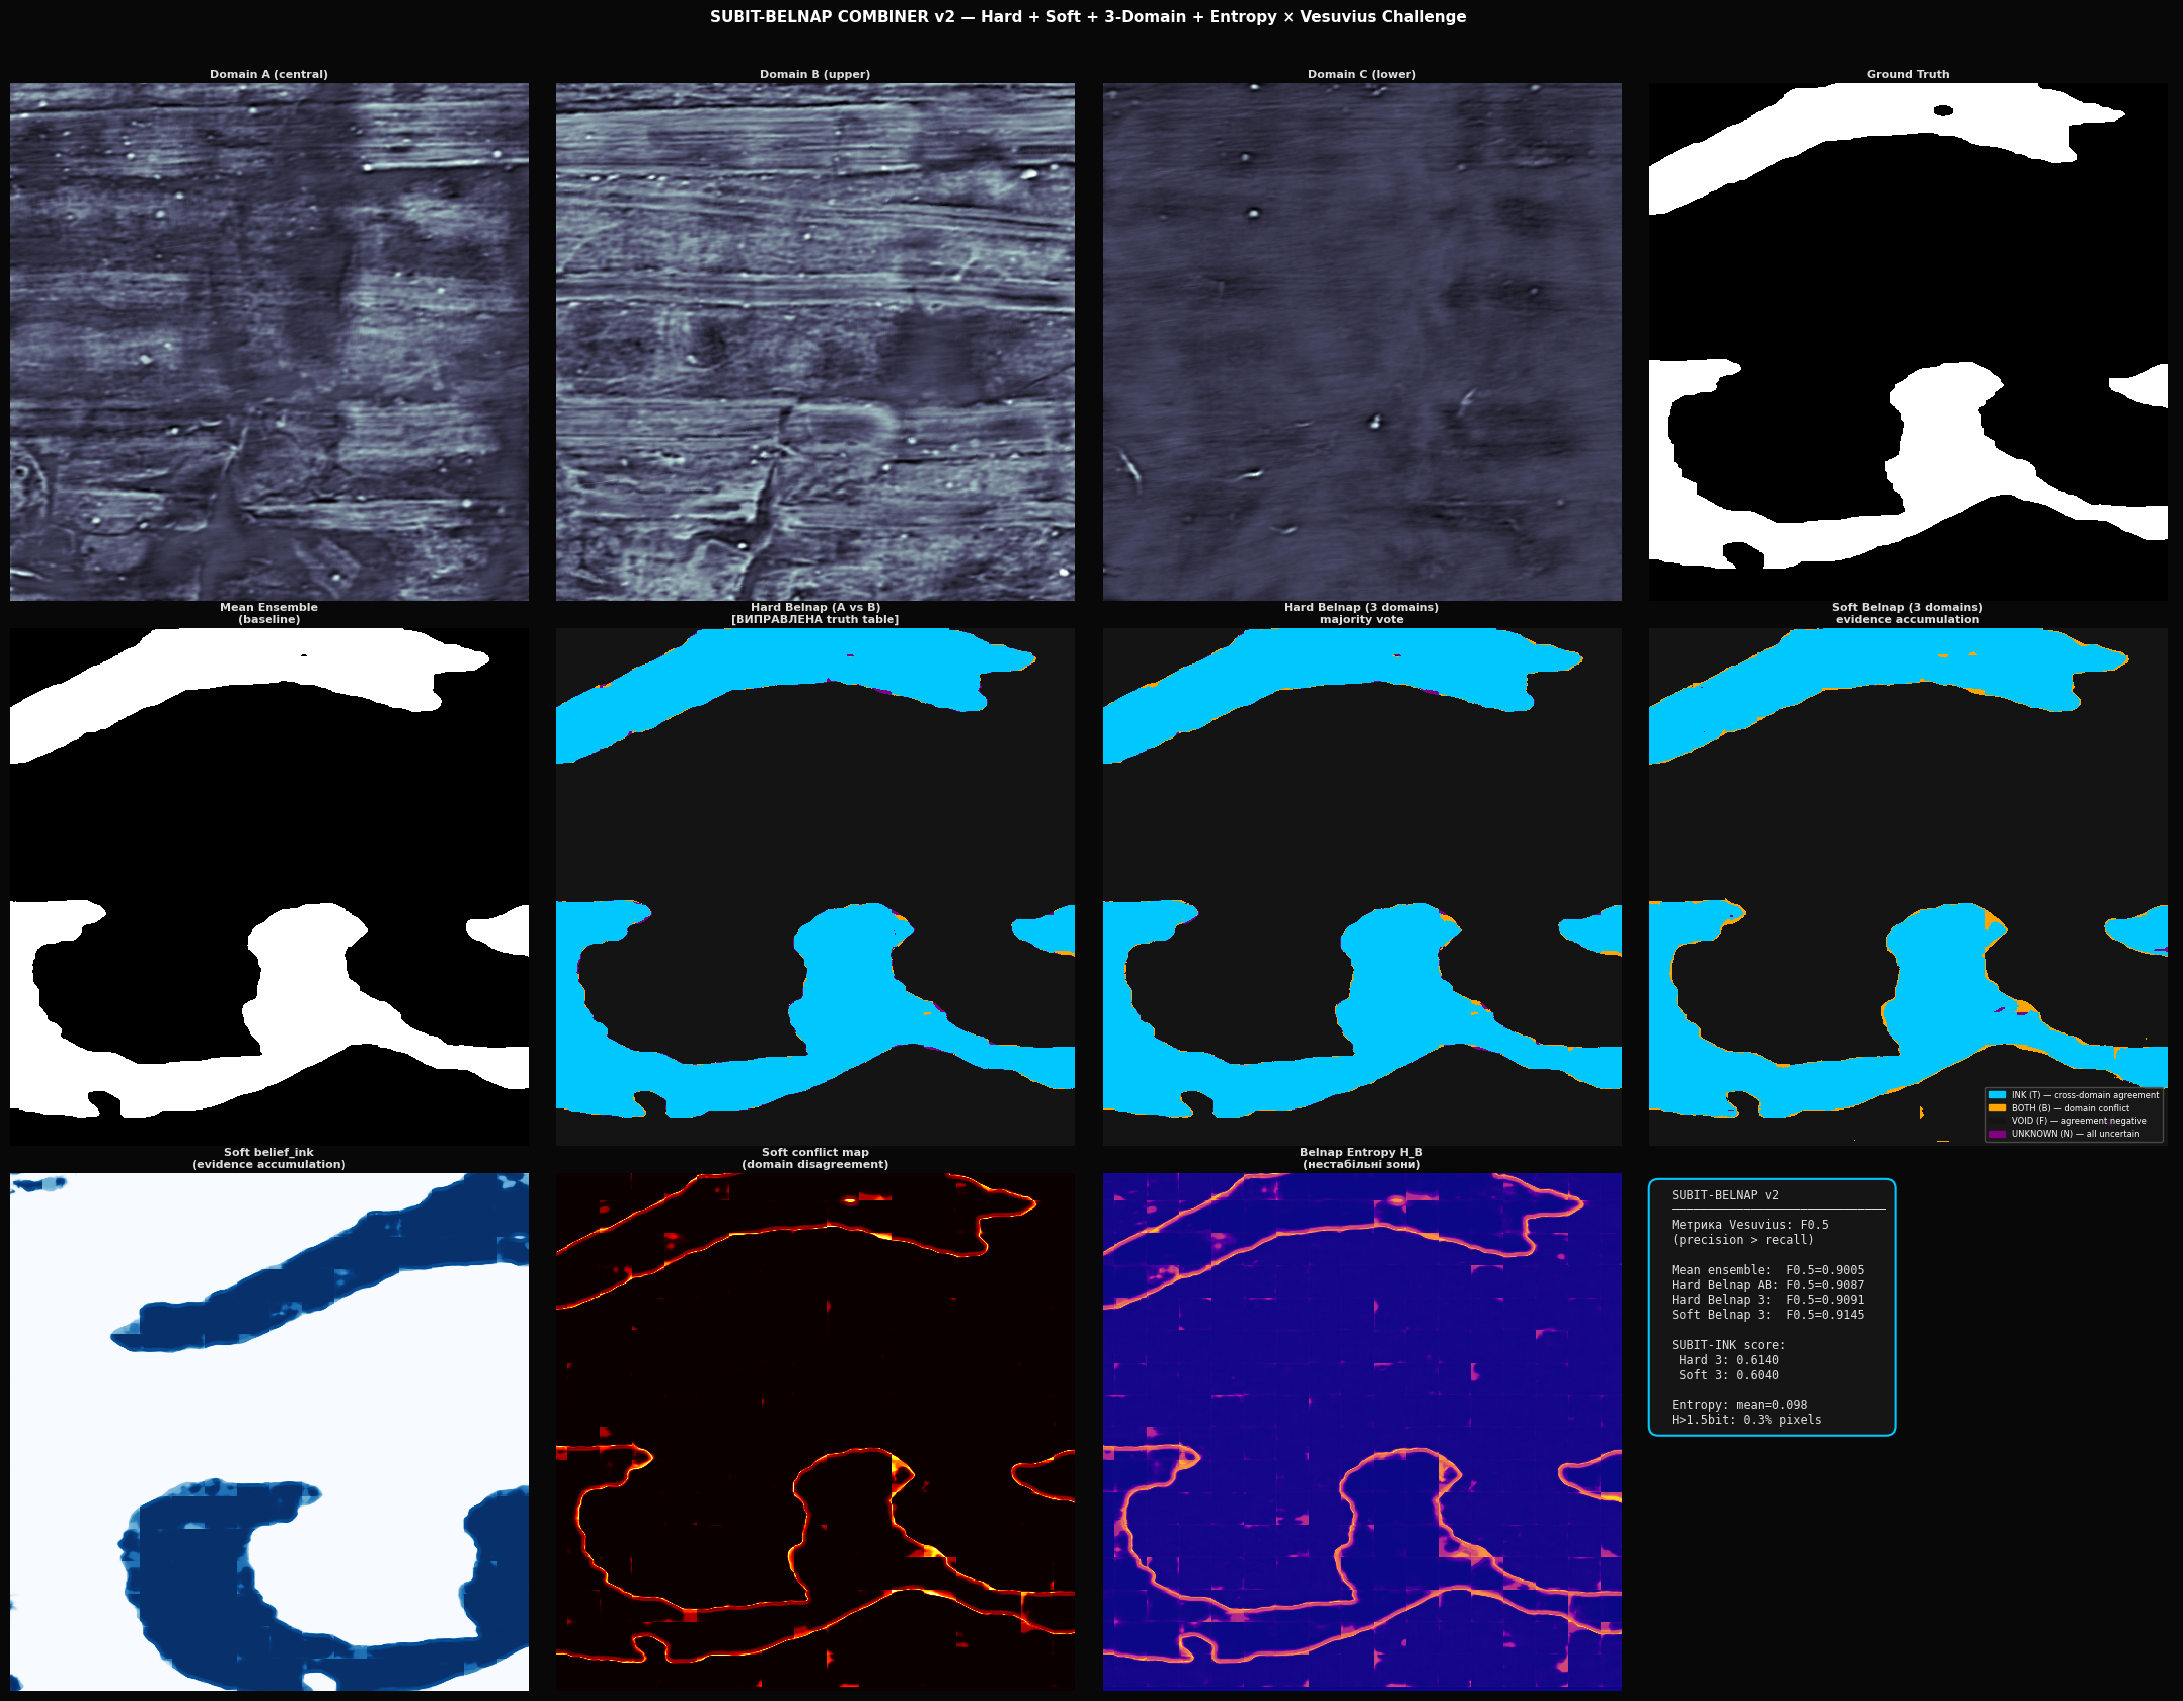

✓ Збережено: subit_belnap_v2.png


In [10]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 7 — Візуалізація
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
iy2,ix2=np.where(ink>0); cy2,cx2=int(iy2.mean()),int(ix2.mean())
SZ=512; sy1=max(0,min(cy2-SZ//2,ink.shape[0]-SZ)); sx1=max(0,min(cx2-SZ//2,ink.shape[1]-SZ))
def crop(a): return a[sy1:sy1+SZ,sx1:sx1+SZ]
 
tA=crop(vol_A); tB=crop(vol_B); tC=crop(vol_C); ink_c=crop(ink)
pAc=crop(prob_A); pBc=crop(prob_B); pCc=crop(prob_C)
hAB_c=crop(hard_AB); h3_c=crop(hard_3); sm_c=crop(soft_map)
ens_c=crop(ensemble); ent_c=crop(entropy_map)
 
def to_rgb(bmap):
    rgb=np.zeros((SZ,SZ,3),dtype=np.uint8)
    for s,c in BELNAP_COLORS.items(): rgb[bmap==s]=c
    return rgb
 
fig,axes=plt.subplots(3,4,figsize=(22,17))
fig.patch.set_facecolor('#080808')
for ax in axes.flat:
    ax.set_facecolor('#0d0d0d'); [sp.set_edgecolor('#2a2a2a') for sp in ax.spines.values()]
def show(ax,img,t,cmap='gray',vmin=None,vmax=None):
    ax.imshow(img,cmap=cmap,interpolation='nearest',vmin=vmin,vmax=vmax)
    ax.set_title(t,color='#ddd',fontsize=8,pad=4,fontweight='bold'); ax.axis('off')
 
# Рядок 1: домени + prob maps
show(axes[0,0],tA,'Domain A (central)','bone')
show(axes[0,1],tB,'Domain B (upper)','bone')
show(axes[0,2],tC,'Domain C (lower)','bone')
show(axes[0,3],ink_c,'Ground Truth','gray')
 
# Рядок 2: Belnap maps
show(axes[1,0],ens_c,'Mean Ensemble\n(baseline)','gray')
axes[1,1].imshow(to_rgb(hAB_c),interpolation='nearest')
axes[1,1].set_title('Hard Belnap (A vs B)\n[ВИПРАВЛЕНА truth table]',color='#ddd',fontsize=8,pad=4,fontweight='bold')
axes[1,1].axis('off')
axes[1,2].imshow(to_rgb(h3_c),interpolation='nearest')
axes[1,2].set_title('Hard Belnap (3 domains)\nmajority vote',color='#ddd',fontsize=8,pad=4,fontweight='bold')
axes[1,2].axis('off')
axes[1,3].imshow(to_rgb(sm_c),interpolation='nearest')
axes[1,3].set_title('Soft Belnap (3 domains)\nevidence accumulation',color='#ddd',fontsize=8,pad=4,fontweight='bold')
axes[1,3].axis('off')
patches=[mpatches.Patch(color=np.array(c)/255,label=BELNAP_LABELS[s])
         for s,c in BELNAP_COLORS.items()]
axes[1,3].legend(handles=patches,loc='lower right',fontsize=6,
                 facecolor='#1a1a1a',edgecolor='#555',labelcolor='white')
 
# Рядок 3: аналіз
show(axes[2,0],(soft['belief_ink'] [:SZ,:SZ] if sm_c.shape==(SZ,SZ) else
                crop(soft['belief_ink'])),'Soft belief_ink\n(evidence accumulation)','Blues',0,1)
show(axes[2,1],(crop(soft['conflict'])),'Soft conflict map\n(domain disagreement)','hot',0,1)
show(axes[2,2],ent_c,'Belnap Entropy H_B\n(нестабільні зони)','plasma',0,2)
 
ax=axes[2,3]; ax.axis('off')
sc3=subit_ink_score(h3_c,ink_c,crop(border.astype(float)).astype(bool))
sc_s=subit_ink_score(sm_c,ink_c,crop(border.astype(float)).astype(bool))
txt=(f'  SUBIT-BELNAP v2\n  {"─"*30}\n'
     f'  Метрика Vesuvius: F0.5\n  (precision > recall)\n\n'
     f'  Mean ensemble:  F0.5={f05_ens:.4f}\n'
     f'  Hard Belnap AB: F0.5={f05_AB:.4f}\n'
     f'  Hard Belnap 3:  F0.5={f05_3:.4f}\n'
     f'  Soft Belnap 3:  F0.5={f05_s:.4f}\n\n'
     f'  SUBIT-INK score:\n'
     f'   Hard 3: {sc3["subit_ink_score"]:.4f}\n'
     f'   Soft 3: {sc_s["subit_ink_score"]:.4f}\n\n'
     f'  Entropy: mean={entropy_map.mean():.3f}\n'
     f'  H>1.5bit: {(entropy_map>1.5).mean()*100:.1f}% pixels')
ax.text(0.03,0.97,txt,transform=ax.transAxes,color='#e0e0e0',
        fontsize=8.5,va='top',fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8',facecolor='#151515',edgecolor='#00c8ff',lw=1.5))
 
plt.suptitle('SUBIT-BELNAP COMBINER v2 — Hard + Soft + 3-Domain + Entropy × Vesuvius Challenge',
             color='white',fontsize=11,fontweight='bold',y=0.998)
plt.tight_layout(rect=[0,0,1,0.985])
plt.savefig('/kaggle/working/subit_belnap_v2.png',dpi=150,bbox_inches='tight',facecolor='#080808')
plt.show()
print('✓ Збережено: subit_belnap_v2.png')

In [11]:
# ════════════════════════════════════════════════════════════════
# КЛІТИНКА 8 — Збереження і summary
# ════════════════════════════════════════════════════════════════
import json
 
results = {
    'f05_ensemble':  float(f05_ens),
    'f05_hard_AB':   float(f05_AB),
    'f05_hard_3':    float(f05_3),
    'f05_soft_3':    float(f05_s),
    'subit_score_hard3': float(sc3['subit_ink_score']),
    'subit_score_soft3': float(sc_s['subit_ink_score']),
    'entropy_mean':  float(entropy_map.mean()),
    'entropy_high_pct': float((entropy_map>1.5).mean()*100),
}
with open('/kaggle/working/results_v2.json','w') as f:
    json.dump(results, f, indent=2)
 
print('\nФайли у /kaggle/working/:')
for ff in sorted(os.listdir('/kaggle/working')):
    size=os.path.getsize(f'/kaggle/working/{ff}')/1e6
    print(f'  {ff}  ({size:.1f} MB)')
print('\n✓ Готово! Output → Download')
 


Файли у /kaggle/working/:
  .virtual_documents  (0.0 MB)
  entropy.npy  (2.2 MB)
  hard_3.npy  (2.2 MB)
  hard_AB.npy  (2.2 MB)
  model_A.pth  (7.8 MB)
  model_B.pth  (7.8 MB)
  model_C.pth  (7.8 MB)
  prob_A.npy  (2.2 MB)
  prob_B.npy  (2.2 MB)
  prob_C.npy  (2.2 MB)
  results_v2.json  (0.0 MB)
  soft_map.npy  (2.2 MB)
  subit_belnap_v2.png  (1.8 MB)

✓ Готово! Output → Download
